# Solve cartpole with REINFORCE

> By Jonas Busk ([jbusk@dtu.dk](mailto:jbusk@dtu.dk))

**2019 update:** Changes have been made to the display of environments due to the previous `viewer` being incompatible with newer versions of Gym.

**2022 update:** Rendering was disabled, and the notebook now uses the `colabgymrender` package to render a video.

**2023 update:** Changed to packages `gymnasium` and `renderlab`, and to `CartPole-v1`.

In this part, we will create an agent that can learn to solve the [cartpole problem](https://gymnasium.farama.org/environments/classic_control/cart_pole/) from OpenAI Gym by applying a simple policy gradient method called REINFORCE.
In the cartpole problem, we need to balance a pole on a cart that moves along a track by applying left and right forces to the cart.

We will implement a probabilistic policy, that given a state of the environment, $s$, outputs a probability distribution over available actions, $a$:

$$
p_\theta(a|s)
$$

The policy is a neural network with parameters $\theta$ that can be trained with gradient descent.
When the set of available actions is discrete, we can use a network with softmax output do describe the distribution.
The core idea of training the policy network is quite simple: *we want to maximize the expected total reward by increasing the probability of good actions and decreasing the probability of bad actions*. 

To achieve this, we apply the gradient of the expected discounted total reward (return):

$$
\begin{align}
\nabla_\theta \mathbb{E}[R|\theta] &= \nabla_\theta \int p_\theta(a|s) R({a}) \, da \\
&= \int \nabla_\theta p_\theta(a|s) R(a)  \, da \\
&= \int p_\theta(a|s) \nabla_\theta \log p_\theta(a|s) R(a) \, da \\
&= \mathbb{E}[\nabla_\theta \log p_\theta(a|s) R(a)]
\end{align}
$$

by definition of expectation and using the identity 

$$
\nabla_\theta p_\theta(a|s) = p_\theta(a|s) \nabla_\theta \log p_\theta(a|s) \ .
$$

The expectation cannot be evaluated analytically, but we have an environment simulator that when supplied with our current policy $p_\theta(a|s)$ can return a sequence of *actions*, *states* and *rewards*. This allows us to replace the integral with a Monte Carlo average:

$$
\nabla_\theta \mathbb{E}[R|\theta] \approx \frac{1}{T} \sum_{t=0}^T \nabla_\theta \log p_\theta(a_t|s_t) R_t \ ,
$$

which is our final gradient estimator, also known as REINFORCE. In the Monte Carlo estimator we run the environment simulator for a predefined number of steps with actions chosen stochastically according to the current stochastic action network $p_\theta(a|s)$.

*Note: For simple reinforcement learning problems (like the one we will address in this exercise) there are simpler methods that work just fine. However, the Policy Gradient method (with some extensions) has been shown to also work well for complex problems with high dimensional inputs and many parameters, where simple methods become inadequate.*

## Policy gradient

In [1]:
!pip install gymnasium
!pip install renderlab
!pip install --upgrade moviepy

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import gymnasium as gym
!pip install opencv-python
import renderlab as rl
!pip install "gymnasium[classic-control]

First we create the environment:

In [3]:
env = gym.make('CartPole-v1') # Create environment

A state in this environment is four numbers describing the position and speed of the cart along with the angle and angular speed of the pole.

There are two available actions: push the cart *left* or *right* encoded as 0 and 1.

In [4]:
s, _ = env.reset()
a = env.action_space.sample()
print('sample state:', s)
print('sample action:', a )

sample state: [-0.00452704  0.02103277 -0.04978741 -0.03544533]
sample action: 0


Let us see how the environment looks when we just take random actions. Note that the episode ends when the pole either 1) is more than 15 degrees from vertical, 2) more outside of the frame or 3) the pole is successfully balanced for some fixed duration.

In [5]:
env_e = gym.make("CartPole-v1", render_mode = "rgb_array") # Create environment
env = rl.RenderFrame(env_e, "./output") # To display environment in the notebook
env.reset() # Reset environment

# Run environment
while True:
    action = env.action_space.sample() # Get a random action
    _, _, done, _, _ = env.step(action) # Take a step
    if done: break # Break if environment is done

env.close() # Close environment
env.play()


Moviepy - Building video temp-{start}.mp4.
Moviepy - Writing video temp-{start}.mp4



Moviepy - Done !
Moviepy - video ready temp-{start}.mp4


Taking random actions does not do a very good job at balancing the pole. Let us now apply the Policy Gradient method described above to solve this task!

Let's first define our network and helper functions.

In [6]:
class PolicyNet(nn.Module):
    """Policy network for reinforcement learning. 
       Takes state inputs and outputs action probabilities."""

    def __init__(self, n_inputs, n_hidden, n_outputs, learning_rate):
        # Initialize superclass (nn.Module)
        super(PolicyNet, self).__init__()
        
        # Define hidden layer: Linear transformation from input to hidden layer
        self.hidden = nn.Linear(n_inputs, n_hidden)
        self.hidden2 = nn.Linear(n_hidden, n_hidden)
        # Define output layer: Linear transformation from hidden layer to output
        self.out = nn.Linear(n_hidden, n_outputs)
        
        # Define optimizer for training the network with given learning rate
        self.optimizer = optim.Adam(self.parameters(), lr=learning_rate)

    def forward(self, x):
        """Forward pass through the network."""
        # Pass input through hidden layer and apply ReLU activation function
        x = self.hidden(x)
        x = F.relu(x)
        # Extra hidden layer
        x = self.hidden2(x) 
        x = F.relu(x)
        # Pass result through output layer
        x = self.out(x)
        
        # Apply softmax activation to produce action probabilities
        return F.softmax(x, dim=1)
    
    def loss(self, action_probabilities, returns):
        """Compute the loss for policy gradient.
        
        Args:
            action_probabilities (tensor): Probabilities of chosen actions.
            returns (tensor): Discounted returns (reward) for each action.
        
        Returns:
            tensor: Negative log likelihood loss.
        """
        # Calculate log of action probabilities, then multiply by returns to weight them
        weighted_log_probs = torch.mul(torch.log(action_probabilities), returns)
        
        # Take the negative mean to compute the final loss for gradient ascent
        return -torch.mean(weighted_log_probs)

In [7]:
def compute_returns(rewards, discount_factor):
    """Compute discounted returns."""
    returns = np.zeros(len(rewards)) # Initialize returns array
    returns[-1] = rewards[-1] # Set last return as last reward
    for t in reversed(range(len(rewards)-1)): # Iterate over reversed range of rewards
        returns[t] = rewards[t] + discount_factor * returns[t+1] # equation is: R_t = r_t + gamma * R_{t+1}
    return returns

To start with, our policy will be a rather simple neural network with one hidden layer. We can retrieve the shape of the state space (input) and action space (output) from the environment.

In [8]:
n_inputs = env.observation_space.shape[0]
n_hidden = 20
n_outputs = env.action_space.n

print('state shape:', n_inputs)
print('action shape:', n_outputs)

state shape: 4
action shape: 2


In [40]:
# Training settings
num_episodes = 5000          # Number of episodes to run
rollout_limit = 2000         # Max rollout length
discount_factor = 0.98        # Reward discount factor (gamma), 1.0 = no discount
learning_rate = 0.001        # Initial learning rate
val_freq = 100               # Validation frequency

# Check if GPU is available and set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Setup policy network and move it to device
policy = PolicyNet(n_inputs, n_hidden, n_outputs, learning_rate).to(device)
print('training on', device)

# Train policy network
try:
    training_rewards, losses = [], []
    print('start training')

    for i in range(num_episodes):
        rollout = []
        s, _ = env_e.reset()
        
        for j in range(rollout_limit):
            # Generate rollout by iteratively evaluating the current policy on the environment
            with torch.no_grad():
                # Move state to GPU and get action probabilities
                s_tensor = torch.from_numpy(np.atleast_2d(s)).float().to(device)
                a_prob = policy(s_tensor)
                
                # Sample action based on probabilities
                a = torch.multinomial(a_prob, num_samples=1).squeeze().cpu().numpy()  # Move back to CPU for env.step
            
            # Take action in environment and get next state, reward
            s1, r, done, _, _ = env_e.step(a)
            rollout.append((s, a, r))
            s = s1  # Update state
            if done: break

        # Prepare batch and move tensors to GPU
        states = torch.from_numpy(np.vstack([x[0] for x in rollout])).float().to(device)
        actions = torch.from_numpy(np.vstack([x[1] for x in rollout])).to(device)
        rewards = np.array([x[2] for x in rollout], dtype=float)
        returns = torch.from_numpy(compute_returns(rewards, discount_factor)).float().to(device)

        # Policy gradient update
        policy.optimizer.zero_grad()
        a_probs = policy(states).gather(1, actions).view(-1)  # Gather action probabilities for taken actions
        loss = policy.loss(a_probs, returns)  # Compute loss
        loss.backward()
        policy.optimizer.step()

        # Bookkeeping
        training_rewards.append(sum(rewards))
        losses.append(loss.item())

        # Validation and printing
        if (i + 1) % val_freq == 0:
            validation_rewards = []
            for _ in range(10):
                s, _ = env_e.reset()
                reward = 0
                for _ in range(rollout_limit):
                    with torch.no_grad():
                        # Move state to GPU for validation
                        s_tensor = torch.from_numpy(np.atleast_2d(s)).float().to(device)
                        a_prob = policy(s_tensor)
                        a = a_prob.argmax().item()  # Get action
                    s, r, done, _, _ = env_e.step(a)
                    reward += r
                    if done: break
                validation_rewards.append(reward)
            
            # Print training progress
            print('{:4d}. mean training reward: {:6.2f}, mean validation reward: {:6.2f}, mean loss: {:7.4f}'.format(
                i + 1,
                np.mean(training_rewards[-val_freq:]),
                np.mean(validation_rewards),
                np.mean(losses[-val_freq:])
            ))

    print('done')
except KeyboardInterrupt:
    print('interrupt')


training on cuda
start training
 100. mean training reward:  26.45, mean validation reward: 278.00, mean loss:  7.7665
 200. mean training reward:  28.72, mean validation reward:  75.90, mean loss:  8.1860
 300. mean training reward:  38.12, mean validation reward: 172.00, mean loss:  9.7784
 400. mean training reward:  43.02, mean validation reward: 295.50, mean loss: 10.4321
 500. mean training reward:  63.57, mean validation reward:  97.80, mean loss: 12.9817
 600. mean training reward:  79.33, mean validation reward: 128.90, mean loss: 14.3787
 700. mean training reward: 102.89, mean validation reward: 171.20, mean loss: 15.3906
 800. mean training reward: 179.54, mean validation reward: 354.80, mean loss: 20.5077
 900. mean training reward: 193.51, mean validation reward: 161.70, mean loss: 21.2868
1000. mean training reward: 166.64, mean validation reward: 356.20, mean loss: 20.3022
1100. mean training reward: 331.30, mean validation reward: 152.10, mean loss: 23.4770
1200. mean 

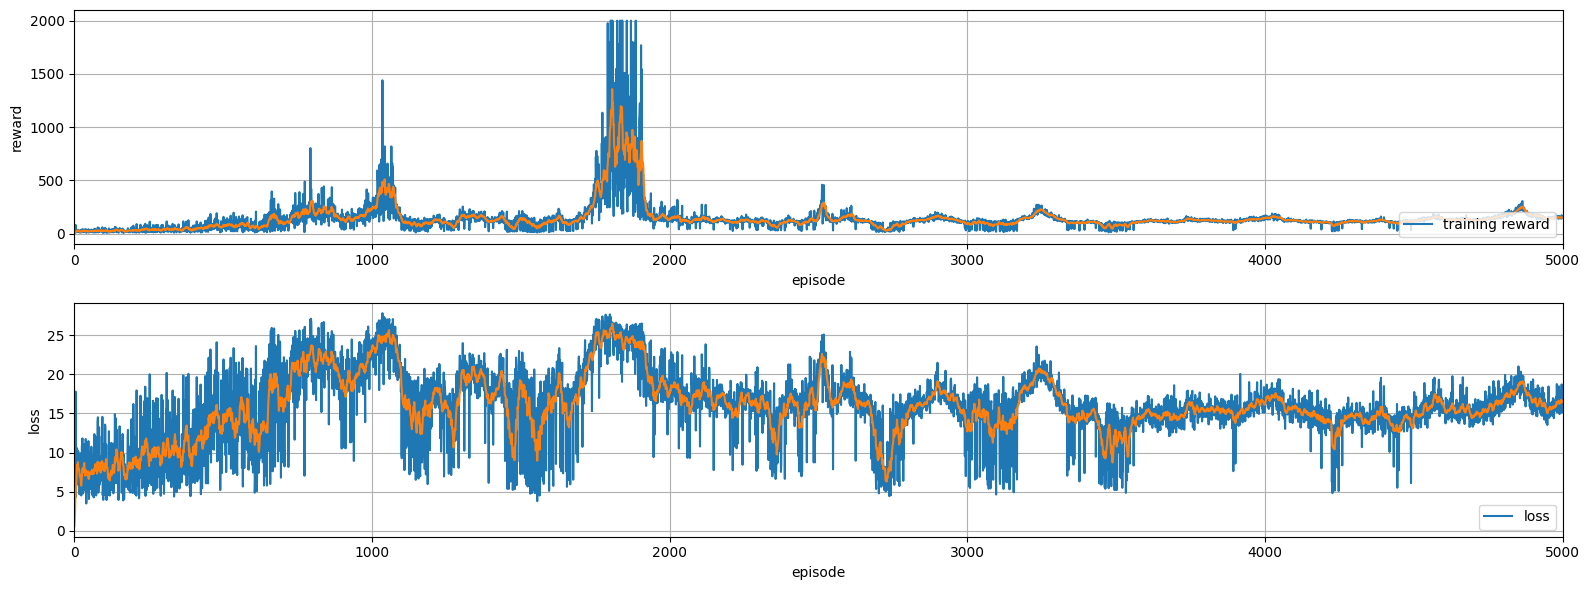

In [41]:
# plot results
def moving_average(a, n=10) :
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret / n

plt.figure(figsize=(16,6))
plt.subplot(211)
plt.plot(range(1, len(training_rewards)+1), training_rewards, label='training reward')
plt.plot(moving_average(training_rewards))
plt.xlabel('episode'); plt.ylabel('reward')
plt.xlim((0, len(training_rewards)))
plt.legend(loc=4); plt.grid()
plt.subplot(212)
plt.plot(range(1, len(losses)+1), losses, label='loss')
plt.plot(moving_average(losses))
plt.xlabel('episode'); plt.ylabel('loss')
plt.xlim((0, len(losses)))
plt.legend(loc=4); plt.grid()
plt.tight_layout(); plt.show()

Now let's review the solution!

In [42]:
# Create wrapper to display environment
env = rl.RenderFrame(env_e, "./gym-results")
s, _ = env.reset()

for _ in range(5000):
    # Move state `s` to the same device as the model
    s_tensor = torch.from_numpy(np.atleast_2d(s)).float().to(device)
    
    # Get the action from the policy network
    a = policy(s_tensor).argmax().item()
    
    # Take the action in the environment
    s, r, done, _, _ = env.step(a)
    
    if done:
        print('done 123')
        break

# Play the environment's rendered frames
env.play()


done 123
Moviepy - Building video temp-{start}.mp4.
Moviepy - Writing video temp-{start}.mp4



Moviepy - Done !
Moviepy - video ready temp-{start}.mp4


## Reducing variance

By default, this gradient estimator has high variance and therefore variance reduction becomes important to learn more complex tasks.
We can reduce variance by subtracting a baseline from the returns, which is unbiased in expectation:

$$
\nabla_\theta \mathbb{E}[R|\theta] \approx \frac{1}{T} \sum_{t=0}^T \nabla_\theta \log p_\theta(a_t|s_t) (R_t-b_t) \ ,
$$

where the baseline, $b_t$, is estimated by the return a timestep $t$ averaged over $V$ rollouts.

$$
b_t = \frac{1}{V} \sum_{v=1}^V R_t^{(v)} \ .
$$

## Exercises

Now it is your turn! Make sure you read and understand the code, then play around with it and try to make it learn better and faster.

Experiment with the:

* number of episodes
* discount factor
* learning rate
* network layers


### Exercise 1 

*Describe any changes you made to the code and why you think they improve the agent. Are you able to get solutions consistently?*

**Answer:**

*Answer here...*

### Exercise 2 

*Consider the following sequence of rewards produced by an agent interacting with an environment for 10 timesteps:*

[0, 1, 1, 1, 0, 1, 1, 0, 0, 0]

* *What is the total reward?*
* *What is the total future reward in each timestep?*
* *What is the discounted future reward in each timestep if $\gamma = 0.9$?*

*Hint: See introdution notebook.*

**Answer:**

*Answer here...*

### Exercise 3

*In the training output, you will sometimes observe the validation reward starts out lower than the training reward but as training progresses they cross over and the validation reward becomes higher than the training reward. How can you explain this behavior?*

*Hint: Do we use the policy network in the same way during training and validation?*

**Answer:**

*Answer here...*

### Exercise 4

*How does the policy gradient method we have used address the exploration-exploitation dilemma?*

*Hint: See the introduction notebook about exploration-exploitation.*

**Answer:**

*Answer here...*

### Exercise 5 [optional]

Extend the code above to reduce variance of the gradient estimator by computing and subtracting the baseline estimate. 

*Hint: You need to sample a batch of rollouts (now we sample just one) for each update in order to compute the baseline, $b_t$.*